In [1]:
# Imports
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn import metrics

In [2]:
FOLDER = "TestResults/"
SNIPPET_LENS = [100, 75, 50, 25, 10 ,5]

dats = {x:[] for x in SNIPPET_LENS}

for k in dats:
    with open(FOLDER+"all_results_"+str(k)+"_with_author_.jsonl", 'r', encoding='utf-8') as reader:
        for l in reader:
            dats[k] += [json.loads(l.strip())]

In [3]:
df_ovo_hpfvs = {k:pd.DataFrame.from_dict(dats[k]).sort_values('keylist_id') for k in dats}
df_ovo_hpfvs[100]['sniplen'] = df_ovo_hpfvs[100]['sniplen'].apply(lambda x: int(x))

In [4]:
#Load FinBERT results

with open(FOLDER+"FinBERT_results.json") as reader:
    res = json.loads(reader.read())['results']

temp = []
for n,r in res.items():
    temp.append({'keylist_id':n, 'f1':r})

fbt_df = pd.DataFrame.from_dict(temp).sort_values('keylist_id')
fbt_df['keylist_id'] = fbt_df['keylist_id'].apply(lambda x: int(x))
fbt_df = fbt_df.sort_values('keylist_id')

In [5]:
print(np.mean(fbt_df['f1']))

0.4417191240565455


In [6]:
to_plot = df_ovo_hpfvs[100][df_ovo_hpfvs[100]['sniplen'] == 100].sort_values('f1', ascending=False)['keylist_id'].reset_index(drop=True)

print(to_plot[:20].to_numpy().tolist())

[41, 81, 34, 8, 64, 69, 35, 13, 73, 96, 89, 84, 38, 70, 4, 43, 16, 67, 14, 31]


In [7]:
# Fixed color mapping for consistent colors across all plots
SNIPLEN_COLORS = {
    100:   '#1f77b4',   # blue
    75:  '#ff7f0e',   # orange
    50:  '#2ca02c',   # green
    25:  '#d62728',   # red
    10:  '#9467bd',   # purple
    5: '#8c564b',   # brown
    'FinBERT': '#e377c2'  # pink
}


def getLineplotKeylistsCustom(df_dict, sniplen=None, num_splits=None, finbert=False,
                               ranked=False, custom_100_label=None, finbert_shared_rank=False):
    """Plot results ordered by split id (0-99) or ranked by mean f1 (best to worst).
    df_dict is a dict of dataframes keyed by sniplen.

    Parameters:
    -----------
    finbert_shared_rank : bool
        If True AND both sniplen and num_splits are defined AND ranked is True,
        FinBERT results are plotted using the same split ordering as the
        ranked sniplen splits. This shows how FinBERT performs on the same
        splits that the sniplen model found easiest → hardest.
    """
    fig, ax = plt.subplots(figsize=(15, 8))

    sniplens_to_plot = [sniplen] if sniplen else SNIPPET_LENS

    label_entries = []  # collect (sort_key, label, color, last_y)
    shared_rank_mapping = None  # will store the sniplen's rank mapping if needed

    for sl in sniplens_to_plot:
        if sl not in df_dict:
            continue
        snip_df = df_dict[sl].copy()
        snip_df['keylist_id'] = pd.to_numeric(snip_df['keylist_id'])
        if num_splits:
            snip_df = snip_df.sort_values('keylist_id').head(num_splits)

        if ranked:
            mean_f1 = snip_df.groupby('keylist_id')['f1'].mean().sort_values(ascending=False)
            rank_mapping = {kid: rank + 1 for rank, kid in enumerate(mean_f1.index)}
            snip_df['rank'] = snip_df['keylist_id'].map(rank_mapping)
            x_col = 'rank'

            # Store ranking if shared ranking is requested for a single sniplen
            if finbert_shared_rank and sniplen and num_splits:
                shared_rank_mapping = rank_mapping
        else:
            x_col = 'keylist_id'

        color = SNIPLEN_COLORS.get(sl, None)
        sns.lineplot(data=snip_df, x=x_col, y='f1', estimator='mean', linewidth=5 if sniplen else 2,
                     errorbar=('ci', 99), n_boot=1000, sort=True,
                     color=color, ax=ax)

        if sniplen:
            ax.set_ylim(0.25, 0.7)
        else:
            ax.set_ylim(0.25, 0.7)

        last_y = ax.lines[-1].get_ydata()[-1]
        label_entries.append((sl, str(sl), color, last_y))

        ax.set_ylabel("Macro f1", fontsize=16)
        ax.set_xlabel("Permutations ranked by f1 scores (rankings are independent for each text length)" if ranked else "", fontsize=16)
        if sniplen == 100:
            ax.set_xlabel("Permutations ranked by f1 scores", fontsize=16)
        ax.tick_params(axis='y', which='major', labelsize=16)
        if not ranked:
            ax.set_xticklabels([])
            ax.set_xticks([])

    # Add FinBERT
    if finbert:
        fbt_df_copy = fbt_df.copy()
        fbt_df_copy['keylist_id'] = pd.to_numeric(fbt_df_copy['keylist_id'])

        if ranked:
            if finbert_shared_rank and shared_rank_mapping is not None:
                # Use the sniplen's rank mapping: only keep splits present in that mapping
                fbt_df_copy = fbt_df_copy[fbt_df_copy['keylist_id'].isin(shared_rank_mapping.keys())]
                fbt_df_copy['rank'] = fbt_df_copy['keylist_id'].map(shared_rank_mapping)
                x_col = 'rank'
                label_suffix = 'FinBERT'
            else:
                # Rank FinBERT independently by its own f1
                mean_f1 = fbt_df_copy.groupby('keylist_id')['f1'].mean().sort_values(ascending=False)
                rank_mapping = {kid: rank + 1 for rank, kid in enumerate(mean_f1.index)}
                fbt_df_copy['rank'] = fbt_df_copy['keylist_id'].map(rank_mapping)
                x_col = 'rank'
                label_suffix = 'FinBERT'
        else:
            x_col = 'keylist_id'
            label_suffix = 'FinBERT'

        color = SNIPLEN_COLORS['FinBERT']
        sns.lineplot(data=fbt_df_copy, x=x_col, y='f1', estimator=None,
                     sort=True, linewidth=5 if sniplen else 2,
                     color=color, ax=ax)
        ax.set_ylim(0.25, 0.7)
        if not ranked:
            ax.set_xlabel("")

        # Update xlabel to reflect shared ranking
        if finbert_shared_rank and shared_rank_mapping is not None:
            ax.set_xlabel(f"The first 25 permutations ranked by SVM f1 scores", fontsize=16)

        last_y = ax.lines[-1].get_ydata()[-1]
        label_entries.append((-1, label_suffix, color, last_y))

    # --- Place labels just outside the right boundary of the plot ---
    # Sort: largest sniplen first (top), FinBERT always last (bottom)
    label_entries.sort(key=lambda x: x[0], reverse=True)

    # Start from the actual line endpoints but enforce ordering and boundaries
    y_min, y_max = ax.get_ylim()
    padding = (y_max - y_min) * 0.03
    min_gap = (y_max - y_min) * 0.08  # minimum gap between labels

    # Initialize desired positions from actual line endpoints
    desired_y = [entry[3] for entry in label_entries]

    # Enforce top-to-bottom ordering: if a lower-priority label has a higher y
    # than a higher-priority one, pull it down
    for i in range(1, len(desired_y)):
        if desired_y[i] >= desired_y[i - 1]:
            desired_y[i] = desired_y[i - 1] - min_gap

    # Enforce minimum gap between consecutive labels (push down)
    for i in range(1, len(desired_y)):
        if desired_y[i - 1] - desired_y[i] < min_gap:
            desired_y[i] = desired_y[i - 1] - min_gap

    # Enforce lower boundary: if any label falls below y_min + padding,
    # shift the entire stack up
    lowest = desired_y[-1] if desired_y else y_min
    if lowest < y_min + padding:
        shift = (y_min + padding) - lowest
        desired_y = [y + shift for y in desired_y]

    # Enforce upper boundary: cap at y_max - padding
    highest = desired_y[0] if desired_y else y_max
    if highest > y_max - padding:
        shift = highest - (y_max - padding)
        desired_y = [y - shift for y in desired_y]

    # Place annotations
    for y_pos, (_, label, color, _) in zip(desired_y, label_entries):
        if custom_100_label:
            if label == '100':
                label = custom_100_label
        ax.annotate(
            label,
            xy=(1.0, y_pos),
            xycoords=('axes fraction', 'data'),
            xytext=(10, 0),
            textcoords='offset points',
            fontsize=16,
            verticalalignment='center',
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=4)
        )
    if sniplen and not finbert:
        to_plot = snip_df.sort_values('f1', ascending=False)['f1'].reset_index(drop=True)
        per_50 = np.percentile(to_plot, 50)
        per_90 = np.percentile(to_plot, 90)
        ax.axhline(per_50, color="#E416FF", linestyle='dashed', linewidth=2, label='50th Percentile')
        ax.axhline(per_90, color='#D41159', linestyle='dashed', linewidth=2, label='90th Percentile')

        # Add percentile labels on the right side
        ax.annotate(
            '50th pctl',
            xy=(1.0, per_50),
            xycoords=('axes fraction', 'data'),
            xytext=(10, 0),
            textcoords='offset points',
            fontsize=13,
            verticalalignment='center',
            bbox=dict(facecolor='#E416FF', alpha=0.7, edgecolor='none', pad=3)
        )
        ax.annotate(
            '90th pctl',
            xy=(1.0, per_90),
            xycoords=('axes fraction', 'data'),
            xytext=(10, 0),
            textcoords='offset points',
            fontsize=13,
            verticalalignment='center',
            bbox=dict(facecolor='#D41159', alpha=0.7, edgecolor='none', pad=3)
        )
    # Make room on the right for the labels
    fig.subplots_adjust(right=0.85)
    pass

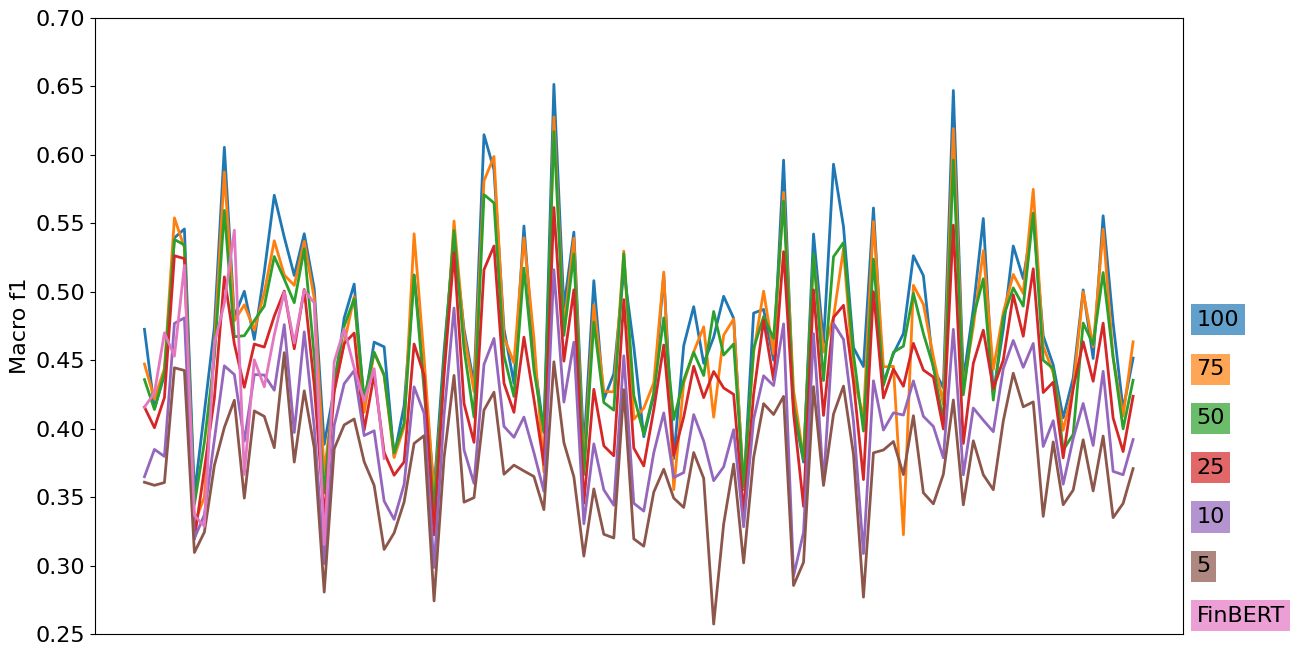

In [8]:
getLineplotKeylistsCustom(df_ovo_hpfvs, finbert=True, ranked=False)

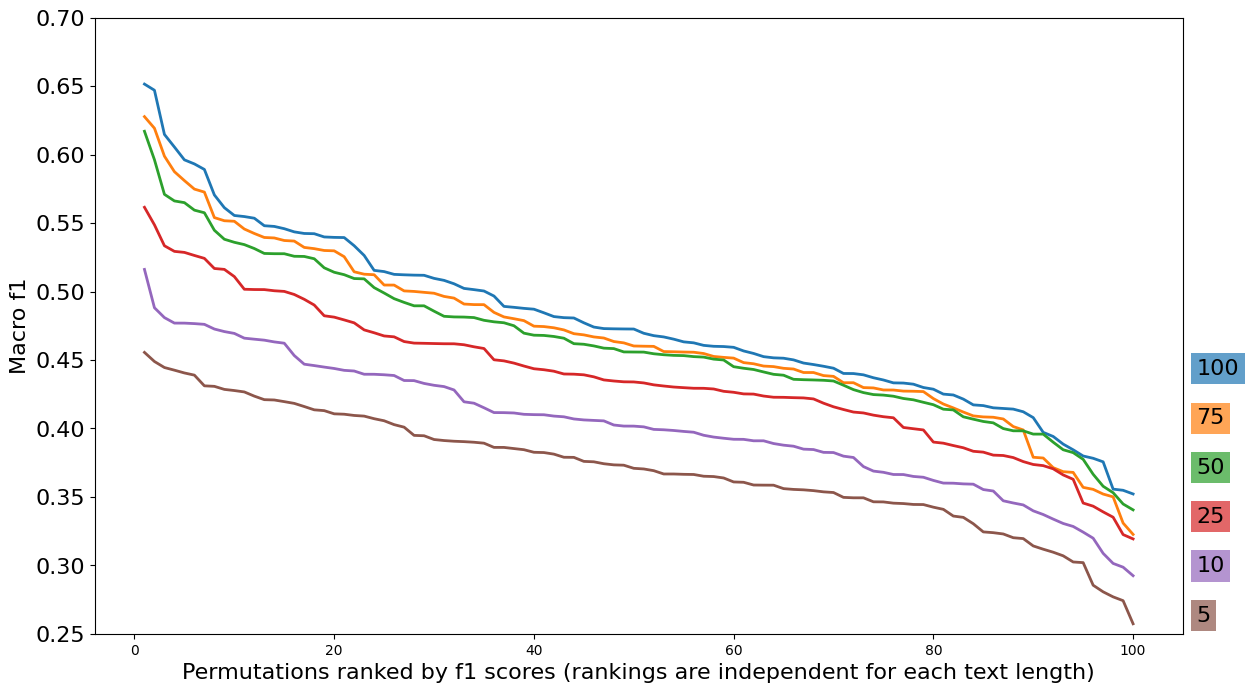

In [9]:
getLineplotKeylistsCustom(df_ovo_hpfvs, finbert=False, ranked=True)

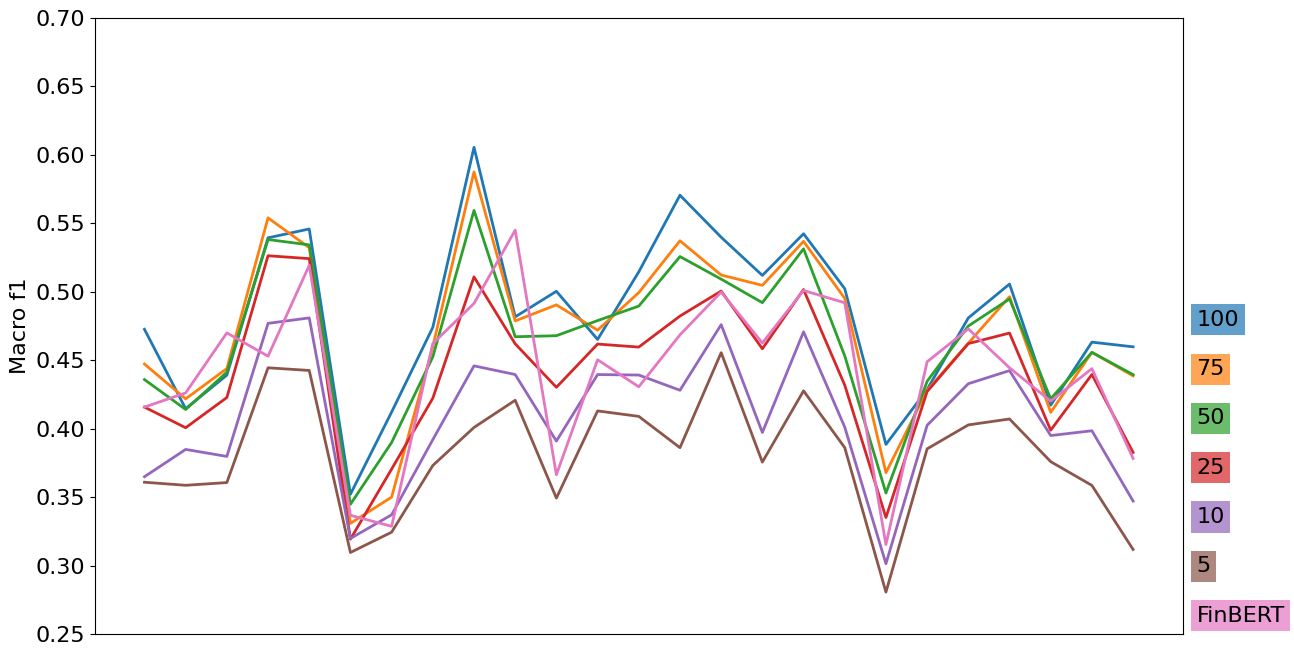

In [10]:
getLineplotKeylistsCustom(df_ovo_hpfvs, num_splits=25, finbert=True, ranked=False)

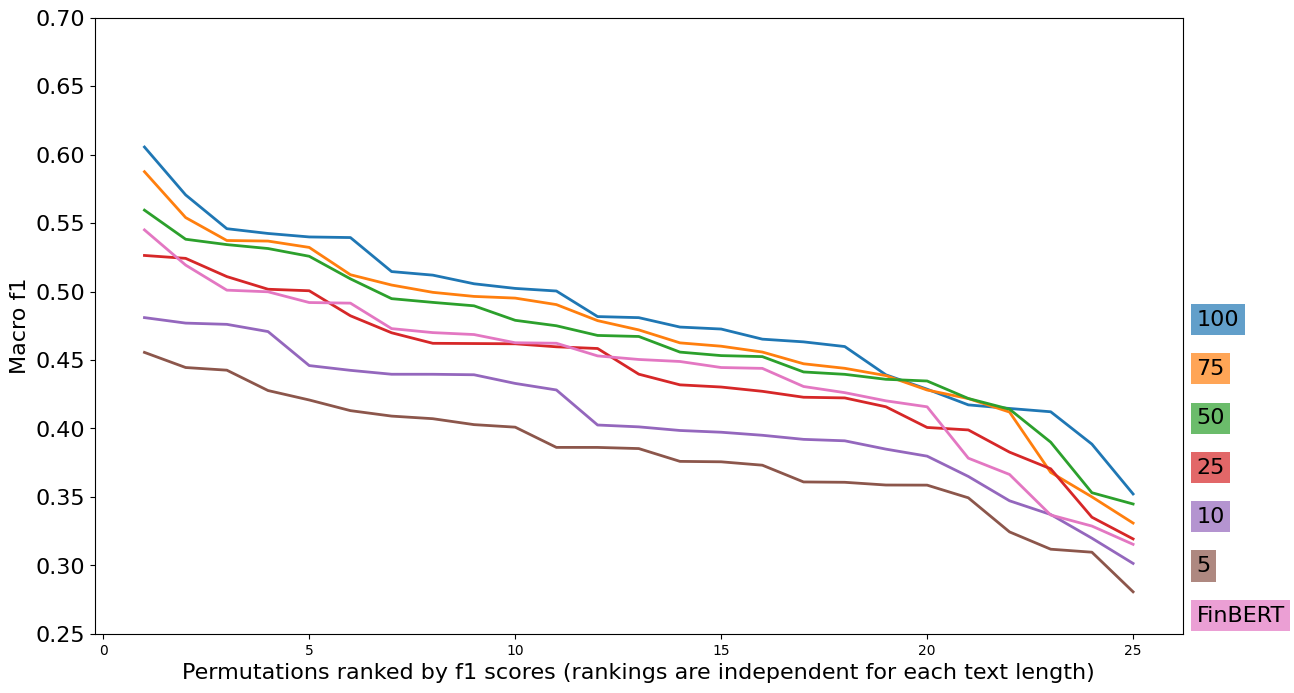

In [11]:
getLineplotKeylistsCustom(df_ovo_hpfvs, num_splits=25, finbert=True, ranked=True)

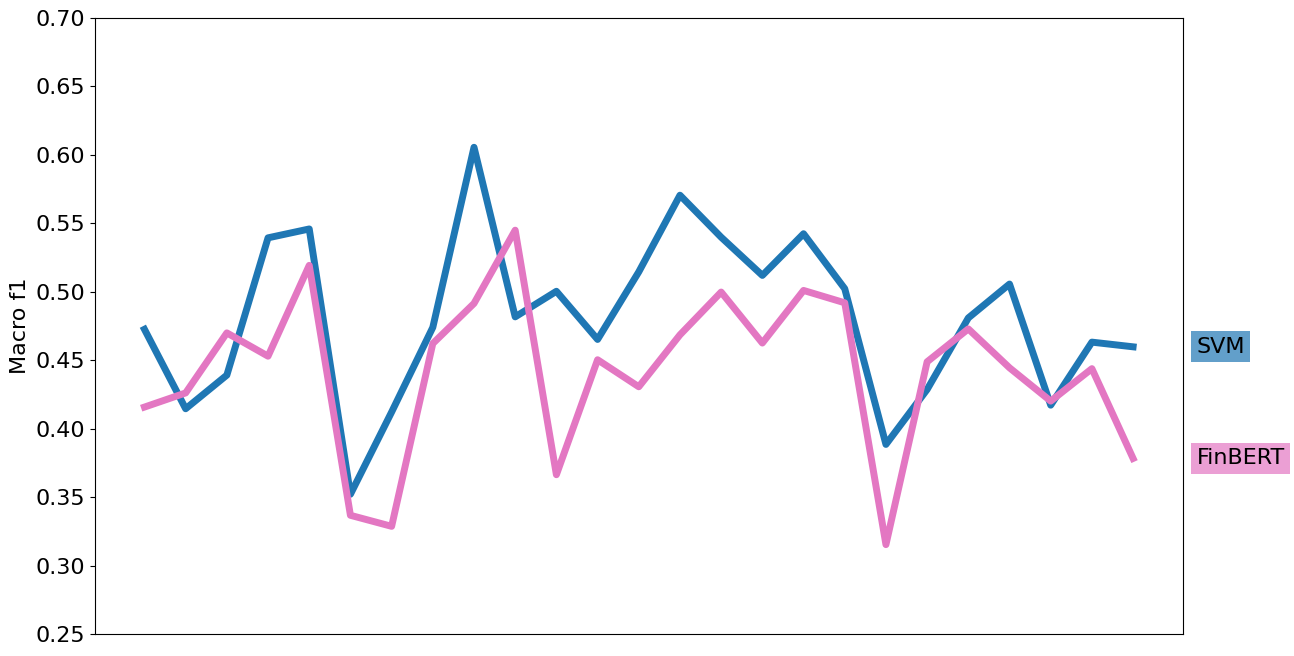

In [12]:
getLineplotKeylistsCustom(df_ovo_hpfvs, 100, num_splits=25, finbert=True, custom_100_label="SVM")

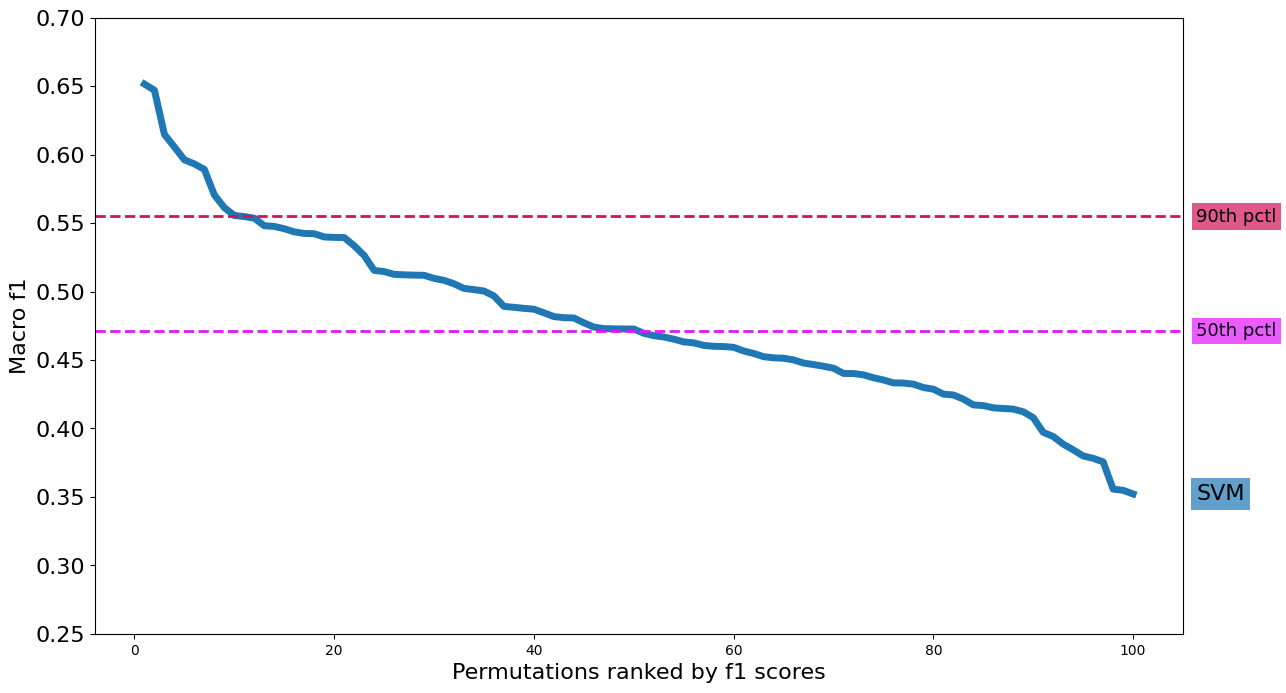

In [13]:
getLineplotKeylistsCustom(df_ovo_hpfvs, 100, ranked=True,  custom_100_label="SVM")

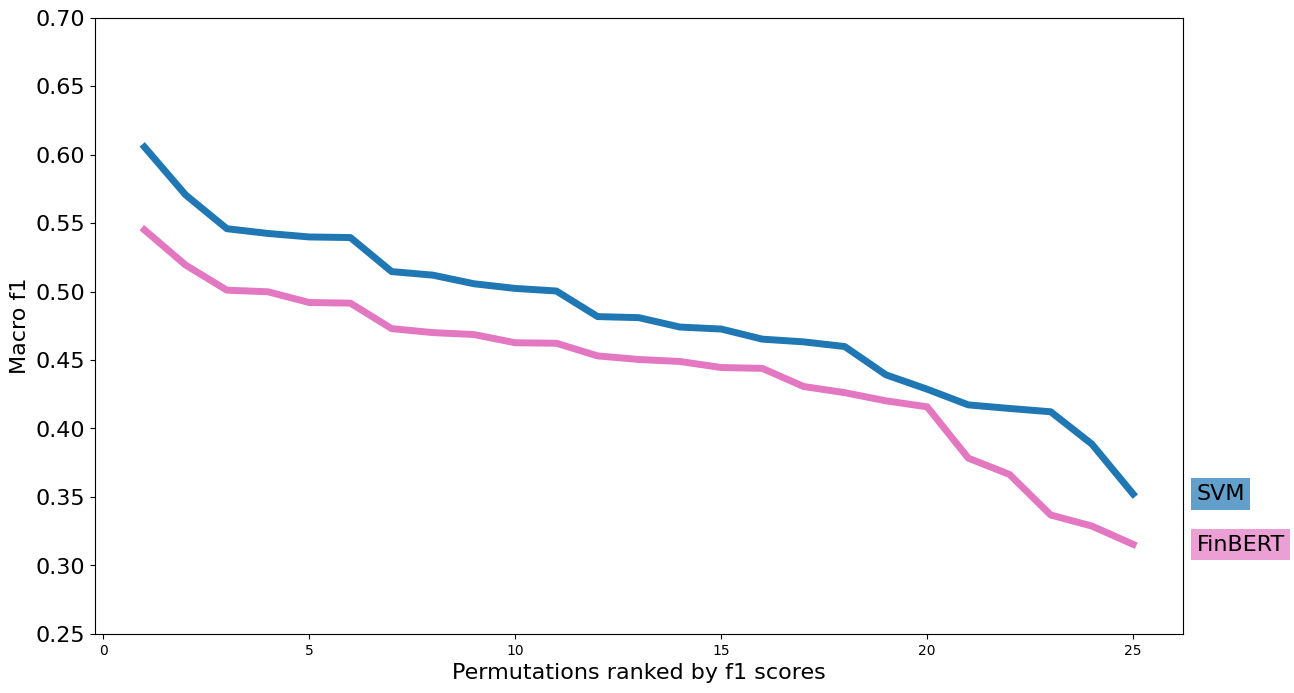

In [14]:
getLineplotKeylistsCustom(df_ovo_hpfvs, 100, num_splits=25, finbert=True, ranked=True,  custom_100_label="SVM")

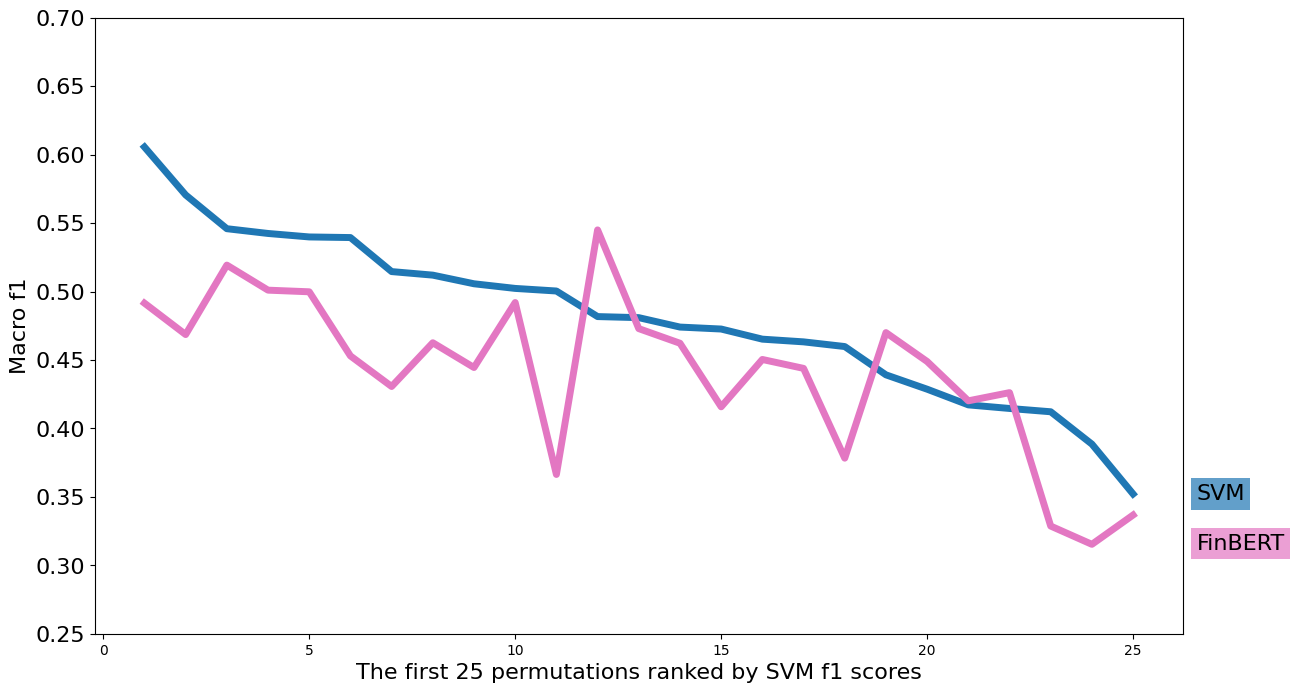

In [15]:
getLineplotKeylistsCustom(df_ovo_hpfvs, 100, num_splits=25, finbert=True, ranked=True,  custom_100_label="SVM", finbert_shared_rank=True)

## Confusion matrix

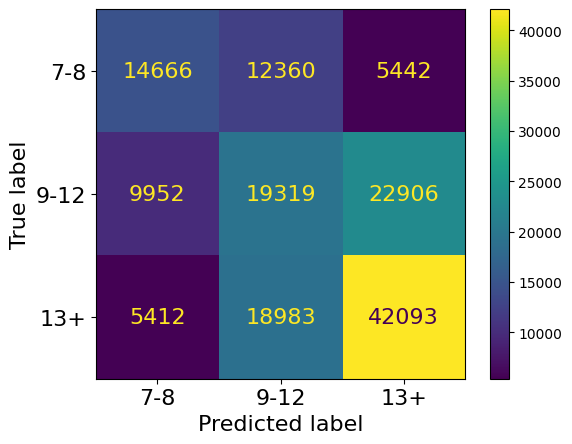

In [16]:
def showCombinedConfMatrix(df):
    best_predicts = np.array(df[df['sniplen']==100].sort_values('f1', ascending=False)['conf_matrix'].to_numpy().tolist())
    best_predicts_aggregated = sum(best_predicts)

    best_labels = df.sort_values('f1', ascending=False)[:1]['labels'].to_numpy()[0]

    def reOrderFromYoungToOld(predicts, labels):
        labels = ['7-8', '9-12', '13+']
        young = np.array([predicts[1][1], predicts[1][2], predicts[1][0]])
        mid = np.array([predicts[2][1], predicts[2][2], predicts[2][0]])
        old = np.array([predicts[0][1], predicts[0][2], predicts[0][0]])
        predicts = np.array([young, mid, old])
        return labels, predicts

    r_lables, r_predicts = reOrderFromYoungToOld(best_predicts_aggregated, best_labels)

    label_font = {'size':'16'}
    p = metrics.ConfusionMatrixDisplay(confusion_matrix=r_predicts, display_labels=r_lables)
    p.plot(text_kw={'size':16}, values_format='')
    plt.gca().axes.tick_params(axis='both', which='major', labelsize=16)
    plt.gca().axes.set_xlabel("Predicted label", fontdict=label_font)
    plt.gca().axes.set_ylabel("True label", fontdict=label_font)
    plt.show()

showCombinedConfMatrix(df_ovo_hpfvs[100])

## Variance experimentation results

In [ ]:
BASE_COVOC_FOLDER = "TestResults/COVOC_FullResult/"
BASE_COVOC_HPFV_END = "_hpfv.json"

def helperParser(file):
    with open(file, 'r') as f:
        return json.loads(f.read())

In [ ]:
loaded_covoc_hpfv_author = []
loaded_covoc_hpfv_no_author = []
loaded_covoc_hpfv_novels = []
for f in os.listdir(BASE_COVOC_FOLDER):
    if f[-11:] == 'r'+BASE_COVOC_HPFV_END and f.find('without') != -1:
        loaded_covoc_hpfv_no_author.append(helperParser(BASE_COVOC_FOLDER+f))
    elif f[-11:] == 'r'+BASE_COVOC_HPFV_END:
        loaded_covoc_hpfv_author.append(helperParser(BASE_COVOC_FOLDER+f))
    elif f[-11:] == 's'+BASE_COVOC_HPFV_END:
        loaded_covoc_hpfv_novels.append(helperParser(BASE_COVOC_FOLDER+f))

In [ ]:
#With author restrictions
df_author = pd.DataFrame.from_dict(loaded_covoc_hpfv_author)
df_author['sniplen'] = df_author['sniplen'].apply(lambda x: int(x))
#Without author restrictions
df_no_author = pd.DataFrame.from_dict(loaded_covoc_hpfv_no_author)
df_no_author['sniplen'] = df_no_author['sniplen'].apply(lambda x: int(x))
#Without author restrictions and excluding non-fiction books and textbooks
df_novels = pd.DataFrame.from_dict(loaded_covoc_hpfv_novels)
df_novels['sniplen'] = df_novels['sniplen'].apply(lambda x: int(x))

In [ ]:
def compareDataframesPlot(dfs: list[pd.DataFrame], titles: list[str], sniplen):
    fig, axs = plt.subplots(1,len(dfs))
    fig.set_size_inches(15, 8)

    y_range = [0.25,0.7]
    x_range = [0,100]
    
    for i in range(len(dfs)):
        df = dfs[i]
        to_plot = df[df['sniplen'] == sniplen].sort_values('f1', ascending=False)['f1'].reset_index(drop=True)
        axs[i].plot(to_plot.to_numpy(), color='#1A85FF')
        #axs[y, x].set_xticks(np.linspace(np.min(to_plot), np.max(to_plot) , 5) - 0.5)
        axs[i].set_title(titles[i], fontsize=20)
        per_50 = np.percentile(to_plot, 50)
        per_90 = np.percentile(to_plot, 90)
        axs[i].axhline(per_50, color="#E416FF", linestyle='dashed', linewidth=2, label='50th Percentile')
        #axs[x].axvline(per_75, color='#D41159', linestyle='dashed', linewidth=2, label='75th Percentile')
        axs[i].axhline(per_90, color='#D41159', linestyle='dashed', linewidth=2, label='90th Percentile')
    for ax in axs.flat:
        x_lim = ax.get_xlim()
        y_lim = ax.get_ylim()
        if x_lim[0] < x_range[0]:
            x_range[0] = x_lim[0]
        if x_lim[1] > x_range[1]:
            x_range[1] = x_lim[1]
        if y_lim[0] < y_range[0]:
            y_range[0] = y_lim[0]
        if y_lim[1] > y_range[1]:
            y_range[1] = y_lim[1]
        ax.set_ylim(0,)
        ax.label_outer()

    for ax in axs.flat:
        ax.set_ylim(y_range)
        ax.set_xlim(x_range)
        ax.tick_params(axis='both', labelsize=20)
        ax.set_xticks([])
        ax.label_outer()
    axs[0].set_ylabel('Macro f1', fontsize=20)

In [ ]:
compareDataframesPlot([df_author, df_no_author, df_novels], ['All genres, author-level', 'All genres, no author-level', 'Novels, no author-level'], sniplen=100)